# Personal Information
Name: **Zakaria Hader**

StudentID: **16347005**

Email: [**zakaria.hader@student.uva.nl**](zakaria.hader@student.uva.nl)

Submitted on: **23.03.2026**

Github repository: [https://github.com/Zakaria0531/thesis-aes](https://github.com/Zakaria0531/thesis-aes)

# Data Context
The dataset used in this project is the ASAP 2.0 [(Automated Student Assessment Prize)](https://www.kaggle.com/datasets/lburleigh/asap-2-0/data) dataset, which contains approximately 24,000 student-written essays. Each essay is annotated with a human-assigned score reflecting writing quality. The dataset includes essays from multiple prompts and grade levels, covering different writing styles such as argumentative and narrative texts.

This dataset is particularly suitable for this research because it consists of human-written essays collected before the widespread use of large language models. This provides a clean baseline for analyzing how AI-based writing assistance affects textual properties and automated essay scoring (AES) metrics.

# Data Description

**Present here the results of your exploratory data analysis. Note that there is no need to have a "story line" - it is more important that you show your understanding of the data and the methods that you will be using in your experiments (i.e. your methodology).**

**As an example, you could show data, label, or group balances, skewness, and basic characterizations of the data. Information about data frequency and distributions as well as results from reduction mechanisms such as PCA could be useful. Furthermore, indicate outliers and how/why you are taking them out of your samples, if you do so.**

**The idea is, that you conduct this analysis to a) understand the data better but b) also to verify the shapes of the distributions and whether they meet the assumptions of the methods that you will attempt to use. Finally, make good use of images, diagrams, and tables to showcase what information you have extracted from your data.**

### Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Data Loading

In [2]:
df = pd.read_csv('ASAP2_train_sourcetexts.csv')
df.head()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


### Analysis 1: Corpus Overview

In this step, I examine the overall structure of the dataset. This includes the number of instances, available variables, data types, and missing values. This helps to understand the basic properties of the dataset before performing deeper analysis.

In [3]:
rows = df.shape[0]
columns = df.shape[1]
print(f"Dataset contains {rows} rows and {columns} columns.\n\n")
df.info()

print("\n\nCheck for number of missing values in each column:")
df.isnull().sum()

Dataset contains 24728 rows and 14 columns.


<class 'pandas.DataFrame'>
RangeIndex: 24728 entries, 0 to 24727
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   essay_id                    24728 non-null  str  
 1   score                       24728 non-null  int64
 2   full_text                   24728 non-null  str  
 3   assignment                  24728 non-null  str  
 4   prompt_name                 24728 non-null  str  
 5   economically_disadvantaged  20723 non-null  str  
 6   student_disability_status   20723 non-null  str  
 7   ell_status                  24286 non-null  str  
 8   race_ethnicity              24724 non-null  str  
 9   gender                      24728 non-null  str  
 10  source_text_1               24728 non-null  str  
 11  source_text_2               4005 non-null   str  
 12  source_text_3               4005 non-null   str  
 13  source_text_4             

essay_id                          0
score                             0
full_text                         0
assignment                        0
prompt_name                       0
economically_disadvantaged     4005
student_disability_status      4005
ell_status                      442
race_ethnicity                    4
gender                            0
source_text_1                     0
source_text_2                 20723
source_text_3                 20723
source_text_4                 22769
dtype: int64

The dataset contains 24728 essays and 14 variables. The main variables used in this study are `essay_id`, `full_text`, and `score`. No critical missing values are observed in these variables, so they can be used directly for further analysis.

There are lots of missing values in the source_text columns, and the economically_disadvantaged, student_disability_status, ell_status columns, but these are not relevant for this research, so I will not be concerned about them.

### Analysis 2: Text Length Statistics

Since this is a text dataset, it is important to analyze basic properties of the essays such as length. These features are especially relevant because they are often used in automated essay scoring systems and may be affected by LLM-based writing assistance.

In [4]:
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['full_text'].apply(lambda x: len(str(x)))

df[['word_count', 'char_count']].describe()

,word_count,char_count
count,24728.000000,24728.000000
mean,362.897282,2035.663499
std,148.461603,900.741907
min,150.000000,697.000000
25%,249.000000,1376.000000
50%,338.000000,1881.000000
75%,446.000000,2501.000000
max,1656.000000,20459.000000


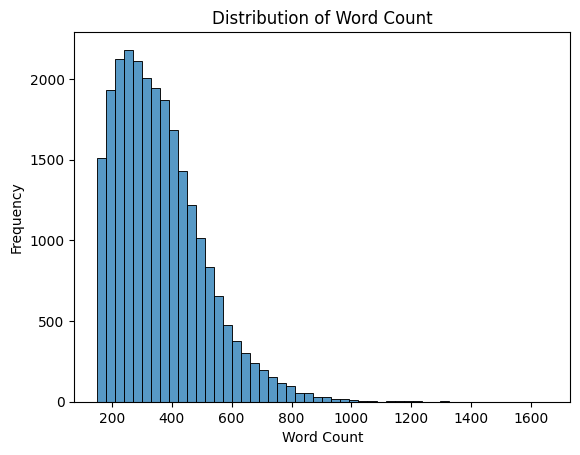

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['word_count'], bins=50)
plt.title("Distribution of Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

The distribution of word counts is right-skewed, meaning that most essays are relatively short, while a smaller number of essays are much longer. The majority of essays fall roughly between 200 and 500 words, with a peak around the lower end of this range. 

There is a long tail extending toward higher word counts, with some essays exceeding 1000 words. These can be considered potential outliers, but since I'm not too considered with predicting I will not remove them, as they may be relevant for understanding the full range of essay lengths in the dataset.

This pattern is important because essay length is often correlated with higher scores in automated essay scoring systems. Since LLM-based writing assistance may increase the length of essays, this skewed distribution suggests that such interventions could artificially shift essays toward higher-scoring regions without necessarily improving underlying writing quality.

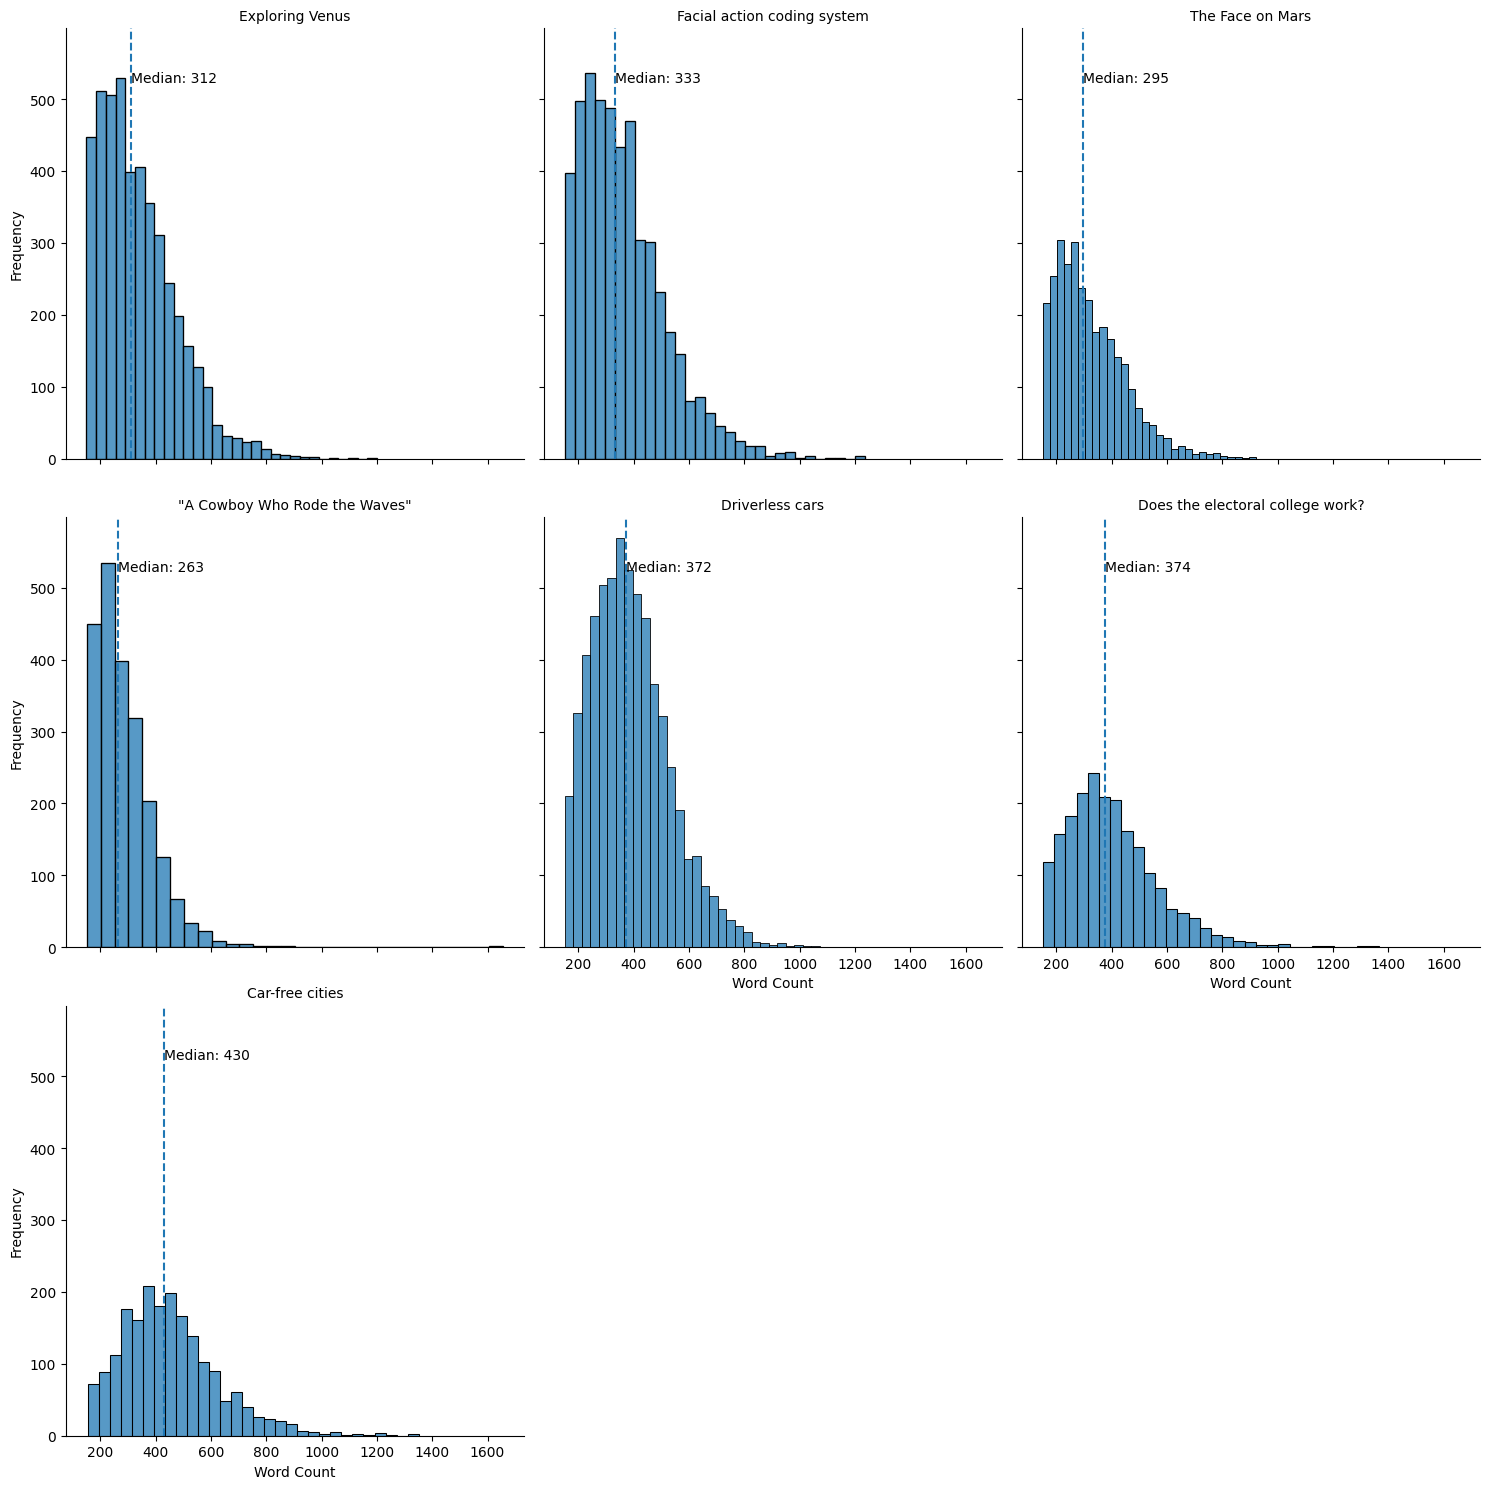

In [6]:
import numpy as np

g = sns.FacetGrid(df, col="prompt_name", col_wrap=3, height=5)
g.map(sns.histplot, "word_count", bins=30)

for ax, prompt in zip(g.axes.flat, df['prompt_name'].unique()):
    subset = df[df['prompt_name'] == prompt]
    median_wc = subset['word_count'].median()
    
    ax.axvline(median_wc, linestyle='--')
    ax.text(median_wc, ax.get_ylim()[1]*0.9, f"Median: {int(median_wc)}",
            rotation=0, verticalalignment='top')

g.set_titles("{col_name}")
g.set_axis_labels("Word Count", "Frequency")

plt.show()

All prompts show right-skewed word count distributions, indicating that there's way more essays that are relatively short with fewer longer essays. Median lengths differ across prompts, with "Car-free cities" producing the longest essays and "A Cowboy Who Rode the Waves" the shortest. This confirms that essay length is strongly prompt-dependent, which is important since length-related features may influence scoring and be affected by LLM-based editing.

### Analysis 3: Score Distribution

Although the primary goal of this research is not to predict essay scores, it is important to understand the distribution of the target variable. This provides a baseline for evaluating how automated scoring metrics behave.

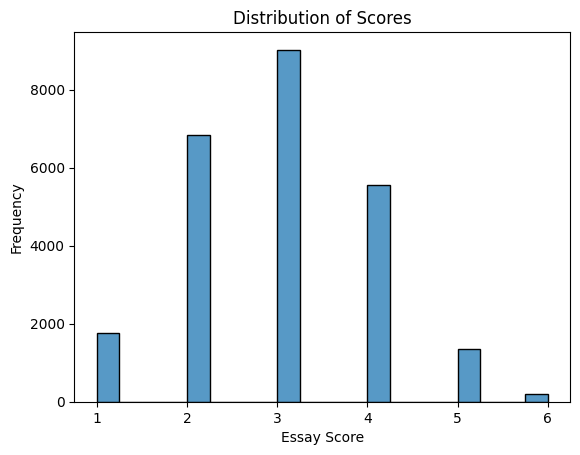

count    24728.000000
mean         2.939987
std          1.035991
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          6.000000
Name: score, dtype: float64

In [7]:
sns.histplot(df['score'], bins=20)
plt.title("Distribution of Scores")
plt.xlabel("Essay Score")
plt.ylabel("Frequency")
plt.show()

df['score'].describe()

The distribution of essay scores shows that most essays receive mid-range scores, with a clear concentration around scores 2, 3, and 4. The median score is 3, and the mean is approximately 2.94, indicating a fairly balanced distribution centered around average performance.

Lower scores (1) and higher scores (5 and 6) occur less frequently, suggesting that extreme performance, either very weak or very strong, is less present in this dataset. This indicates that the dataset is dominated by essays of moderate quality.

This distribution is important for later analysis because it establishes a baseline for automated scoring behavior. Since most essays fall within a narrow score range, small changes in textual features, such as those introduced by LLM-based writing assistance, may shift essays into higher score categories.

In [8]:
df['score'].describe()
df.groupby('prompt_name')['score'].agg(['min', 'max']).rename(columns={'min': 'Min Score', 'max': 'Max Score'})

,Min Score,Max Score
prompt_name,,
"""A Cowboy Who Rode the Waves""",1,5
Car-free cities,1,6
Does the electoral college work?,1,6
Driverless cars,1,6
Exploring Venus,1,6
Facial action coding system,1,6
The Face on Mars,1,6


The score ranges differ slightly across prompts. Most prompts have a scoring range from 1 to 6, while one prompt ("A Cowboy Who Rode the Waves") has a maximum score of 5. This indicates that scoring criteria are not entirely uniform across prompts.

This variation is important because it means that scores are not directly comparable across all essays without considering the prompt. In later experiments, this should be taken into account, for example by analyzing prompts separately or normalizing scores.

Additionally, differences in scoring ranges may affect how automated scoring systems interpret essay quality, and how sensitive they are to changes introduced by LLM-based interventions.

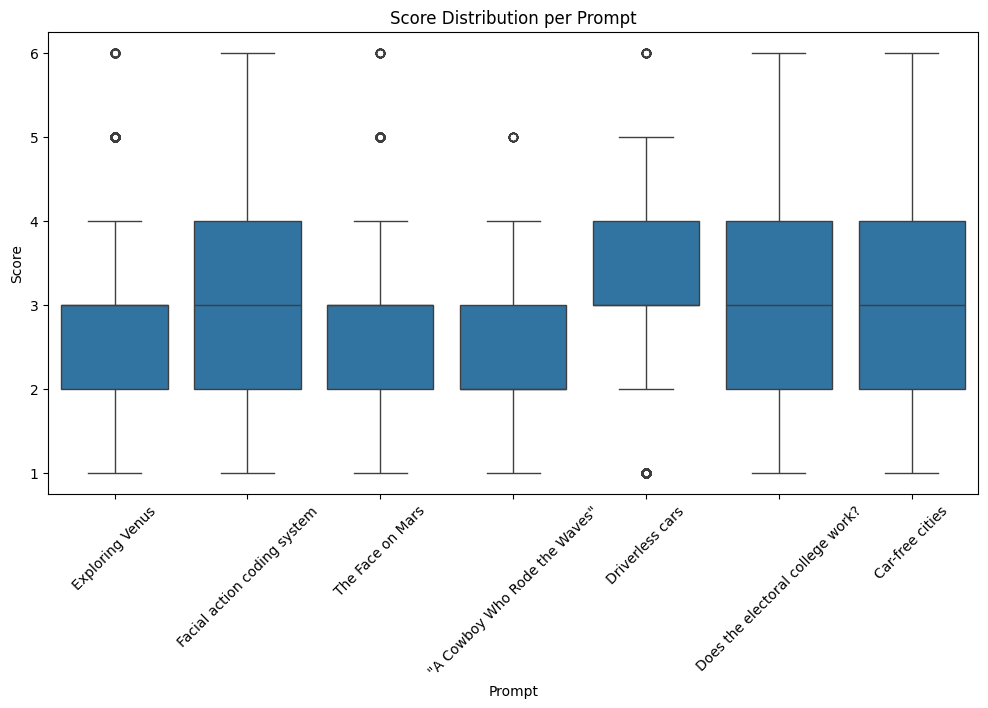

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.boxplot(x='prompt_name', y='score', data=df)

plt.title("Score Distribution per Prompt")
plt.xlabel("Prompt")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

The score distributions vary across prompts, although most prompts show a similar overall pattern with median scores around 3. This indicates that the dataset is generally centered around moderate-quality essays across all topics.

Some prompts, such as "Driverless cars", show slightly higher median scores and a more concentrated distribution in the upper range (3–4), suggesting that essays for this prompt may be evaluated more favorably or are easier to score higher on. In contrast, prompts like "Exploring Venus" and "The Face on Mars" show slightly lower medians and more spread toward lower scores.

### Analysis 4: Relationship Between Essay Length and Score

This analysis examines whether longer essays tend to receive higher scores. This is a known thing in automated essay scoring and is particularly relevant because LLMs may increase text length during editing.

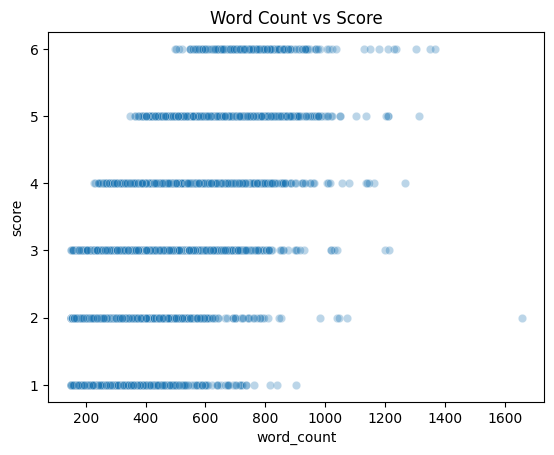

In [10]:
sns.scatterplot(x='word_count', y='score', data=df, alpha=0.3)
plt.title("Word Count vs Score")
plt.show()

There appears to be a positive relationship between essay length and score. This suggests that surface-level features such as length may influence scoring. This is important for my research because I will modify essays using LLMs, which may change length, and therefore indirectly influence scoring metrics.

### Analysis 5: Prompt Distribution

This analysis examines how essays are distributed across different prompts and whether scoring differs per prompt.

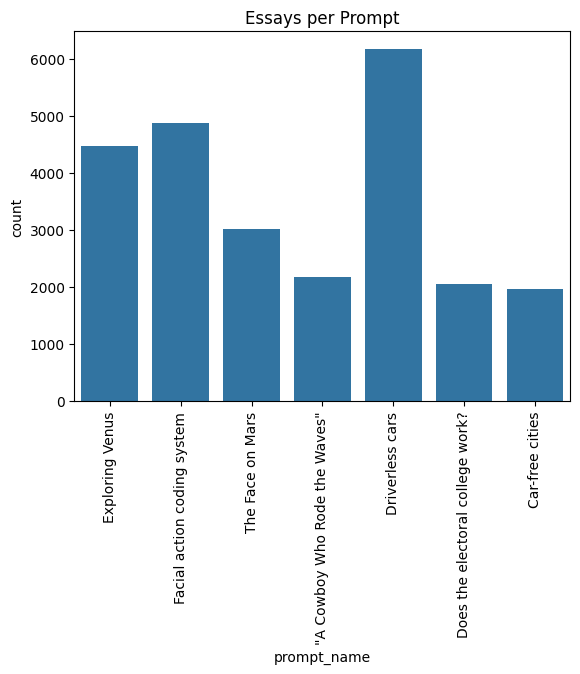

In [11]:
df['prompt_name'].value_counts()

sns.countplot(x='prompt_name', data=df)
plt.title("Essays per Prompt")
#rotate x-axis labels for better readability
plt.xticks(rotation=90)
plt.show()

The number of essays varies considerably across prompts, with "Driverless cars" having the highest number of responses, while prompts like "Car-free cities" and "Does the electoral college work?" have significantly fewer. This indicates an imbalance in the dataset, which may influence analysis and model behavior, as prompts with more data could dominate overall patterns.

### Other Analysis

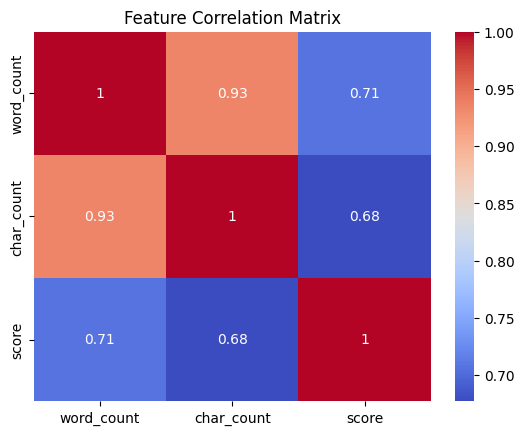

In [12]:
df[['word_count', 'char_count', 'score']].corr()
sns.heatmap(df[['word_count', 'char_count', 'score']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

This very basic correlation matrix shows a very strong relationship between word count and character count (0.93), which is expected since both measure text length. More importantly, there is a clear positive correlation between essay length and score, with word count (0.71) and character count (0.68) both moderately to strongly correlated with scores. This suggests that longer essays tend to receive higher scores, indicating that surface-level features such as length play a significant role in automated essay scoring.

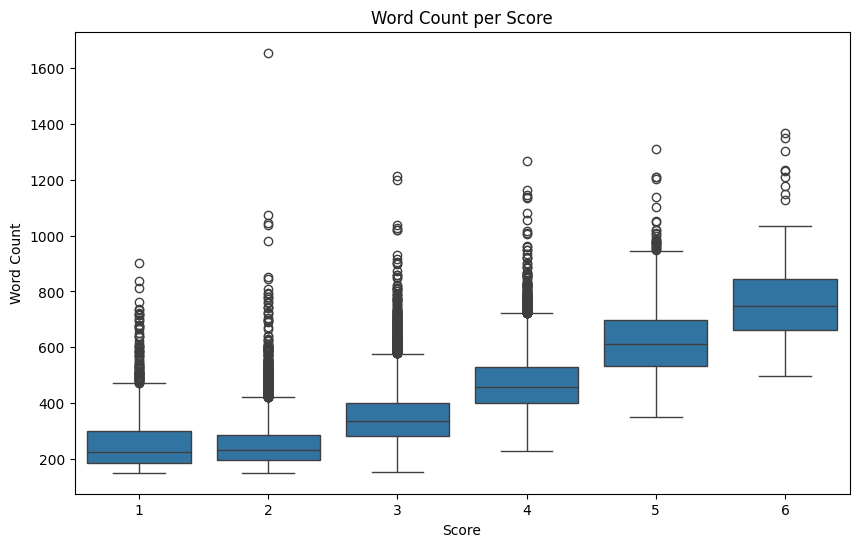

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x='score', y='word_count', data=df)
plt.title("Word Count per Score")
plt.xlabel("Score")
plt.ylabel("Word Count")
plt.show()

The boxplot verifies again that word count is positively correlated with score, as higher-scoring essays tend to have higher median word counts. However, there is considerable overlap in word counts across score categories, indicating that length alone does not determine scores.

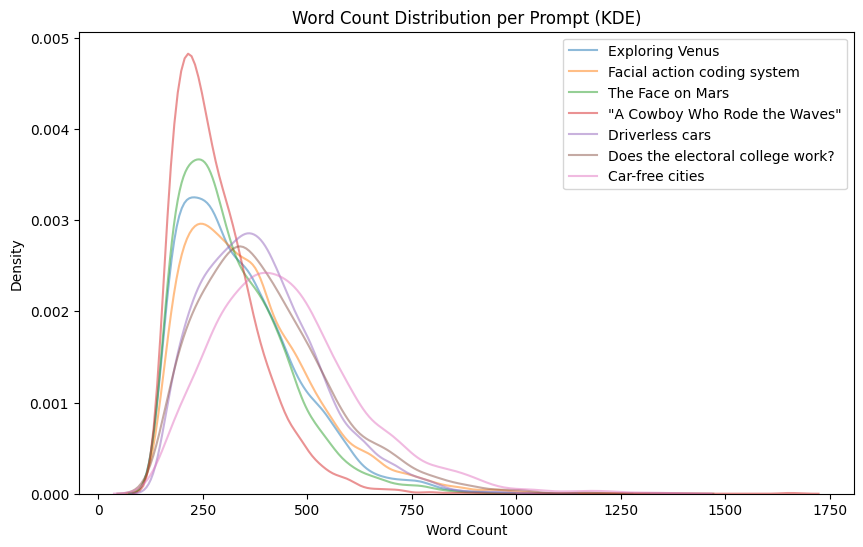

In [14]:
plt.figure(figsize=(10,6))

for prompt in df['prompt_name'].unique():
    subset = df[df['prompt_name'] == prompt]
    sns.kdeplot(subset['word_count'], label=prompt, alpha=0.5)

plt.title("Word Count Distribution per Prompt (KDE)")
plt.xlabel("Word Count")
plt.legend()
plt.show()

The KDE plot shows the distribution of word counts across different prompts, highlighting clear differences in essay length patterns. While all prompts exhibit right-skewed distributions, the peaks and spreads vary noticeably. Prompts such as "Car-free cities" and "Does the electoral college work?" are shifted toward higher word counts, indicating longer essays on average. In contrast, prompts like "A Cowboy Who Rode the Waves" are concentrated around shorter lengths with a sharper peak.

Despite these differences, all prompts display a long tail toward higher word counts, confirming the presence of a smaller number of very long essays. This reinforces the observation that essay length is strongly prompt-dependent, which is important since length-related features may influence scoring and could be affected differently by LLM-based writing assistance.

## Very simple Baseline Model

In [15]:
from sklearn.linear_model import LinearRegression

X = df[['word_count']]
y = df['score']

model = LinearRegression()
model.fit(X, y)

print(model.score(X, y))

0.49962210431467036


As a simple baseline, a linear regression model was trained using only word count as a predictor for essay score. The model achieved an R² score of approximately 0.50, indicating that around 50% of the variance in essay scores can be explained by essay length alone. This is a surprisingly strong result for such a simple feature and confirms earlier observations that surface-level characteristics, such as length, play a significant role in (automated) essay scoring. 

This finding is particularly important for this research, as LLM-based writing assistance may increase essay length, potentially leading to artificially higher scores without necessarily improving writing quality.

## Second Dataset

As an additional dataset for comparison, two suitable options are considered. The first is the original ASAP [Automated Student Assessment Prize](https://www.kaggle.com/c/asap-aes/data) dataset, which is widely used in automated essay scoring research and includes published benchmarks, making it useful for validating model performance against established results. The second option is the dataset proposed as a backup in the thesis design, which focuses on AI-generated versus human-written text and is more aligned with the detection aspect of this research. Using one of these datasets alongside ASAP 2.0 provides a reference point for evaluation and helps ensure that findings are not dataset-specific, improving the robustness and interpretability of the results.